In [9]:
import os
import psycopg2
from psycopg2.extras import RealDictCursor
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import defaultdict

In [10]:
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = int(os.getenv("DB_PORT", "8053"))
DB_NAME = os.getenv("DB_NAME", "postgres")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASS = os.getenv("DB_PASS", "postgres")


def run_query(sql: str):
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASS,
    )
    try:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            cur.execute(sql)
            rows = cur.fetchall()
            return list(rows)
    finally:
        conn.close()


print(f"Connecting to {DB_USER}@{DB_HOST}:{DB_PORT}/{DB_NAME} ...")

Connecting to postgres@localhost:8053/postgres ...


In [11]:
SQL = """
WITH days AS (
  SELECT generate_series(
    date_trunc('day', now() AT TIME ZONE 'UTC') - interval '29 days',
    date_trunc('day', now() AT TIME ZONE 'UTC'),
    interval '1 day'
  ) AS day_ts
)
SELECT
  d.day_ts AS measured_date,
  s.name   AS station,
  AVG(m.temperature_c) AS temperature_c
FROM days d
CROSS JOIN weather_station s
LEFT JOIN weather_measurement m
  ON m.station_id = s.id
 AND date_trunc('day', m.measured_at AT TIME ZONE 'UTC') = d.day_ts
GROUP BY d.day_ts, s.name
ORDER BY d.day_ts, s.name;
"""

RealDictRow({'measured_date': datetime.datetime(2025, 11, 28, 0, 0), 'station': 'Station Center', 'temperature_c': 1.9346852290667231})
RealDictRow({'measured_date': datetime.datetime(2025, 11, 28, 0, 0), 'station': 'Station East', 'temperature_c': 4.785786708092343})
RealDictRow({'measured_date': datetime.datetime(2025, 11, 28, 0, 0), 'station': 'Station North', 'temperature_c': -4.756585503815553})
RealDictRow({'measured_date': datetime.datetime(2025, 11, 28, 0, 0), 'station': 'Station South', 'temperature_c': 7.873660320189142})
RealDictRow({'measured_date': datetime.datetime(2025, 11, 28, 0, 0), 'station': 'Station West', 'temperature_c': 6.374412546559572})


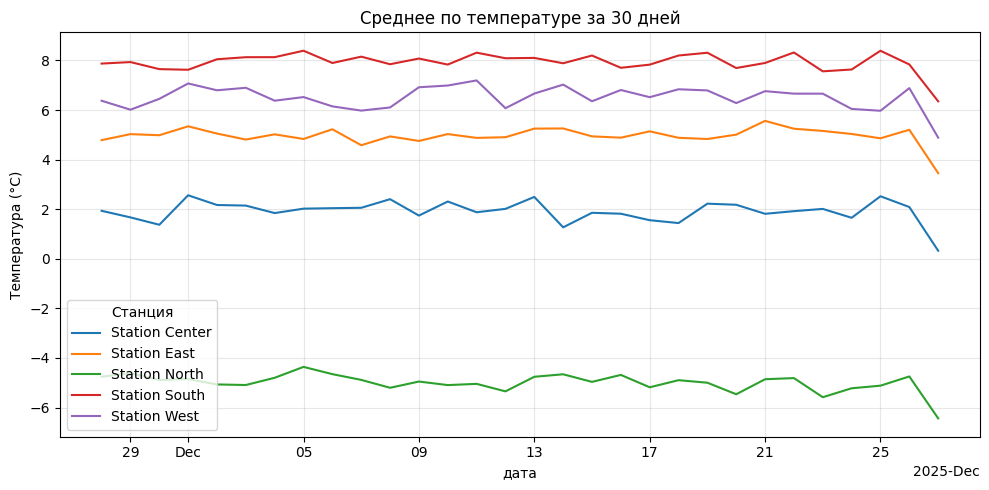

In [12]:
rows = run_query(SQL)

for r in rows[:5]:
    print(r)

series = defaultdict(list)

for r in rows:
    series[r["station"]].append((r["measured_date"], r["temperature_c"]))

for st in series:
    series[st].sort(key=lambda x: x[0])

plt.figure(figsize=(10, 5))

for st, pts in series.items():
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    plt.plot(xs, ys, label=st)

plt.title("Среднее по температуре за 30 дней")
plt.xlabel("дата")
plt.ylabel("Температура (°C)")
plt.legend(title="Станция")
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(mdates.AutoDateLocator())
)
plt.tight_layout()
plt.show()